In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
def recomendar_partidos(df_partidos, perfil_usuario):
    """
    Calcula un score de recomendación para cada partido basado en las preferencias
    del usuario, sus horarios disponibles, y las métricas avanzadas (PCA de FIFA).
    """
    
    # Trabajamos sobre una copia para no modificar el dataset original
    df = df_partidos.copy()
    
    # =====================================================================
    # PASO 1: Calcular la característica dinámica (Horario Libre)
    # =====================================================================
    def verificar_disponibilidad(row):
        utc_offset = perfil_usuario.get('utc_offset', -3) 
        hora_local = (row['match_hora_utc'] + utc_offset) % 24 
        dia = row['day_of_week_num']
        
        horas_libres_del_dia = perfil_usuario['horario_libre'].get(dia, [])
        if hora_local in horas_libres_del_dia:
            return 1.0  
        return 0.0      
    
    df['feature_disponibilidad'] = df.apply(verificar_disponibilidad, axis=1)

    # =====================================================================
    # PASO 2: Extraer y NORMALIZAR los pesos del diccionario del usuario
    # =====================================================================
    pesos_crudos = perfil_usuario['pesos']
    suma_total = sum(pesos_crudos.values())
    pesos = {k: v / suma_total for k, v in pesos_crudos.items()}

    # --- C. Feature de Nacionalidad ---
    pais_usuario = perfil_usuario.get('nacionalidad', '')
    df['feature_nacionalidad'] = (
        (df['home_team'] == pais_usuario) | (df['away_team'] == pais_usuario)
    ).astype(float)
    
    # =====================================================================
    # PASO 3: Calcular el Score Final (Producto Punto)
    # =====================================================================
    # NOTA: PC1 mide Disparidad, por lo que para premiar la "Paridad" lo restamos de 1.
    
    df['Score_Recomendacion'] = (
        (pesos.get('w_nacionalidad', 0)  * df['feature_nacionalidad']) +        
        
        # Rendimiento Colectivo Histórico (ELO)
        (pesos.get('w_calidad_elo', 0)   * df['ELO_match_rating_scaled']) +      
        (pesos.get('w_paridad_elo', 0)   * (1 - df['ELO_diff_scaled'])) +       
        
        # Calidad Individual / Estrellas (FIFA PCA pre-escalado)
        (pesos.get('w_calidad_fifa', 0)  * df['PC2_Calidad_scaled']) +                  
        (pesos.get('w_paridad_fifa', 0)  * (1 - df['PC1_Disparidad_scaled'])) +            
        
        # Contexto del Partido y Usuario
        (pesos.get('w_fin_de_semana', 0) * df['is_weekend']) +                  
        (pesos.get('w_horario_libre', 0) * df['feature_disponibilidad']) +      
        (pesos.get('w_decisivo', 0)      * df['is_decisive'])                   
    )

    # =====================================================================
    # PASO 4: Clasificación por Categorías (Híbrido)
    # =====================================================================
    q_alta = df['Score_Recomendacion'].quantile(0.85)
    q_media = df['Score_Recomendacion'].quantile(0.50)
    
    p_alta = max(q_alta, 0.65)  
    p_media = max(q_media, 0.45) 
    
    def categorizar_partido(score):
        if score >= p_alta:
            return "Imperdible 🌟"
        elif score >= p_media:
            return "Vale la pena 📺"
        else:
            return "Para ver el resumen 📱"
            
    df['Categoria'] = df['Score_Recomendacion'].apply(categorizar_partido)
    
    # =====================================================================
    # PASO 5: Ordenar
    # =====================================================================
    df_recomendado = df.sort_values(by='Score_Recomendacion', ascending=False)
    
    return df_recomendado

In [10]:
matriz_partidos = pd.read_csv("../data/matriz_partidos_scaled_pca.csv", index_col="id_partido")
matriz_partidos

,home_team,away_team,match_number,group_name,is_decisive,day_of_week_num,is_weekend,ELO_match_rating,ELO_diff,home_value,...,match_value_diff,match_hora_utc,ELO_match_rating_scaled,ELO_diff_scaled,match_value_scaled,match_value_diff_scaled,hora_utc_scaled,day_of_week_scaled,PC1_Disparidad_scaled,PC2_Calidad_scaled
id_partido,,,,,,,,,,,,,,,,,,,,,
1,Korea Republic,Czechia,2,A,0,4,0,3478,26,143.400,...,53.025,2,0.484417,0.022135,0.469576,0.448777,0.086957,0.666667,0.030830,0.365019
2,Mexico,South Africa,1,A,0,3,0,3382,334,85.600,...,32.900,19,0.398931,0.423177,0.205817,0.370770,0.826087,0.500000,0.327612,0.266488
3,Czechia,South Africa,25,A,0,3,0,3250,202,196.425,...,143.725,16,0.281389,0.251302,0.378366,0.613715,0.695652,0.500000,0.332037,0.220758
4,Mexico,Korea Republic,28,A,0,4,0,3610,106,85.600,...,57.800,1,0.601959,0.126302,0.353639,0.462953,0.043478,0.666667,0.026405,0.410749
5,South Africa,Korea Republic,54,A,1,3,0,3276,228,52.700,...,90.700,1,0.304541,0.285156,0.308133,0.537336,0.043478,0.500000,0.293906,0.194288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,England,Croatia,22,L,0,2,0,3950,90,1315.000,...,958.700,20,0.904720,0.105469,0.938463,0.930370,0.869565,0.333333,0.192422,0.925956
69,Panama,England,67,L,1,5,1,3757,283,32.850,...,1282.150,21,0.732858,0.356771,0.875099,0.978988,0.913043,0.833333,0.656866,0.750232
70,Ghana,Panama,21,L,0,2,0,3242,232,295.175,...,262.325,23,0.274265,0.290365,0.459189,0.713904,1.000000,0.333333,0.292868,0.181951


In [34]:
# Definimos el arquetipo: Un fanático del buen fútbol parejo, que prioriza un poco 
# que caiga en su horario libre después de trabajar.
usuario_ejemplo = {
    "nacionalidad": "Argentina",
    "utc_offset": -3,
    "pesos": {
        "w_nacionalidad": 0.35,
        "w_calidad_elo": 0.3,      # Pesa 30% el nivel general
        "w_paridad_elo": 0.2,      # Pesa 20% que sea peleado
        "w_calidad_fifa": 0,    # Pesa 15% la calidad del futbol que quiere ver
        "w_paridad_fifa": 0,    # Pesa 10% que los partidos sean parejos
        "w_fin_de_semana": 0.05,    # Pesa 5% si es fin de semana
        "w_horario_libre": 0.20,     # Pesa 20% que caiga en su agenda
        "w_decisivo": 0.10          #Que tanto le importan los últimos partidos del grupo
    },
    "horario_libre": {
        0: [18, 19, 20, 21, 22], # Lunes a Viernes libre desde las 18:00
        1: [18, 19, 20, 21, 22],
        2: [18, 19, 20, 21, 22],
        3: [18, 19, 20, 21, 22],
        4: [18, 19, 20, 21, 22],
        5: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22], # Sábado libre desde mediodía
        6: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]  # Domingo libre desde mediodía
    }
}

In [35]:
df_recomendaciones = recomendar_partidos(matriz_partidos, usuario_ejemplo)

df_recomendaciones.head(10)

,home_team,away_team,match_number,group_name,is_decisive,day_of_week_num,is_weekend,ELO_match_rating,ELO_diff,home_value,...,match_value_scaled,match_value_diff_scaled,hora_utc_scaled,day_of_week_scaled,PC1_Disparidad_scaled,PC2_Calidad_scaled,feature_disponibilidad,feature_nacionalidad,Score_Recomendacion,Categoria
id_partido,,,,,,,,,,,,,,,,,,,,,
58,Argentina,Algeria,19,J,0,2,0,3856,370,765.500,...,0.785198,0.833712,0.043478,0.333333,0.241334,0.742920,1.0,1.0,0.751912,Imperdible 🌟
60,Jordan,Argentina,70,J,1,6,1,3803,423,18.250,...,0.715429,0.888711,0.086957,1.000000,0.745989,0.598296,0.0,1.0,0.686945,Imperdible 🌟
66,Colombia,Portugal,71,K,1,5,1,3959,9,303.950,...,0.857331,0.868224,1.000000,0.833333,0.185877,0.941729,1.0,0.0,0.686517,Imperdible 🌟
46,Uruguay,Spain,66,H,1,5,1,4057,273,361.100,...,0.931471,0.921635,0.000000,0.833333,0.181893,0.964626,1.0,0.0,0.651042,Imperdible 🌟
56,Argentina,Austria,43,J,0,0,0,3940,286,765.500,...,0.794507,0.823495,0.739130,0.000000,0.123233,0.801797,0.0,1.0,0.622174,Vale la pena 📺
69,Panama,England,67,L,1,5,1,3757,283,32.850,...,0.875099,0.978988,0.913043,0.833333,0.656866,0.750232,1.0,0.0,0.582086,Vale la pena 📺
34,Netherlands,Japan,11,F,0,6,1,3865,57,763.000,...,0.795754,0.820378,0.869565,1.000000,0.167134,0.815970,1.0,0.0,0.571841,Vale la pena 📺
18,Scotland,Brazil,49,C,1,2,0,3751,217,207.825,...,0.819771,0.878121,0.956522,0.333333,0.220021,0.746362,1.0,0.0,0.553407,Vale la pena 📺
13,Brazil,Morocco,7,C,0,5,1,3805,163,909.200,...,0.827775,0.870621,0.956522,0.833333,0.065018,0.794042,1.0,0.0,0.535480,Vale la pena 📺


🏆 TOP 10 PARTIDOS RECOMENDADOS:
Pesos: {'w_nacionalidad': 0.35, 'w_calidad_elo': 0, 'w_paridad_elo': 0, 'w_calidad_fifa': 0.3, 'w_paridad_fifa': 0.2, 'w_fin_de_semana': 0.05, 'w_horario_libre': 0.2, 'w_decisivo': 0.1}

  home_team away_team  Score_Recomendacion      Categoria  match_hora_utc  day_of_week_num
  Argentina   Algeria             0.770508   Imperdible 🌟               1                2
    Uruguay     Spain             0.669174   Imperdible 🌟               0                5
   Colombia  Portugal             0.662786   Imperdible 🌟              23                5
  Argentina   Austria             0.638244 Vale la pena 📺              17                0
     Jordan Argentina             0.608576 Vale la pena 📺               2                6
   Scotland    Brazil             0.566587 Vale la pena 📺              22                2
     Brazil   Morocco             0.562674 Vale la pena 📺              22                5
      Japan    Sweden             0.556222 Vale la pe

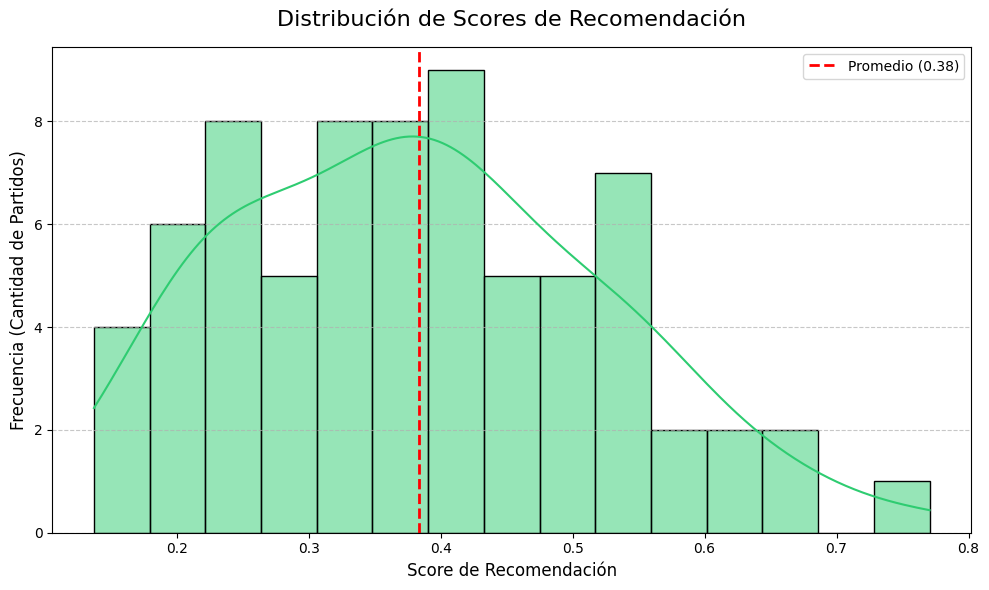

In [33]:
# =====================================================================
# 3. MOSTRAR RESULTADOS Y GRÁFICO
# =====================================================================

# Seleccionamos las columnas más importantes para ver el Top 10
columnas_vista = [
    'home_team', 'away_team', 'Score_Recomendacion', 
    'Categoria','match_hora_utc', 'day_of_week_num'
]

print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(f"Pesos: {usuario_ejemplo["pesos"]}\n")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

# --- Generar el gráfico de distribución ---
plt.figure(figsize=(10, 6))
sns.histplot(
    df_recomendaciones['Score_Recomendacion'], 
    bins=15, 
    kde=True, 
    color='#2ecc71', 
    edgecolor='black'
)

plt.title('Distribución de Scores de Recomendación', fontsize=16, pad=15)
plt.xlabel('Score de Recomendación', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Partidos)', fontsize=12)

# Línea marcando el promedio
promedio = df_recomendaciones['Score_Recomendacion'].mean()
plt.axvline(promedio, color='red', linestyle='dashed', linewidth=2, label=f'Promedio ({promedio:.2f})')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

🏆 TOP 10 PARTIDOS RECOMENDADOS:
Pesos: {'w_nacionalidad': 0.35, 'w_calidad_elo': 0.3, 'w_paridad_elo': 0.2, 'w_calidad_fifa': 0, 'w_paridad_fifa': 0, 'w_fin_de_semana': 0.05, 'w_horario_libre': 0.2, 'w_decisivo': 0.1}

  home_team away_team  Score_Recomendacion      Categoria  match_hora_utc  day_of_week_num
  Argentina   Algeria             0.751912   Imperdible 🌟               1                2
     Jordan Argentina             0.686945   Imperdible 🌟               2                6
   Colombia  Portugal             0.686517   Imperdible 🌟              23                5
    Uruguay     Spain             0.651042   Imperdible 🌟               0                5
  Argentina   Austria             0.622174 Vale la pena 📺              17                0
     Panama   England             0.582086 Vale la pena 📺              21                5
Netherlands     Japan             0.571841 Vale la pena 📺              20                6
   Scotland    Brazil             0.553407 Vale la pe

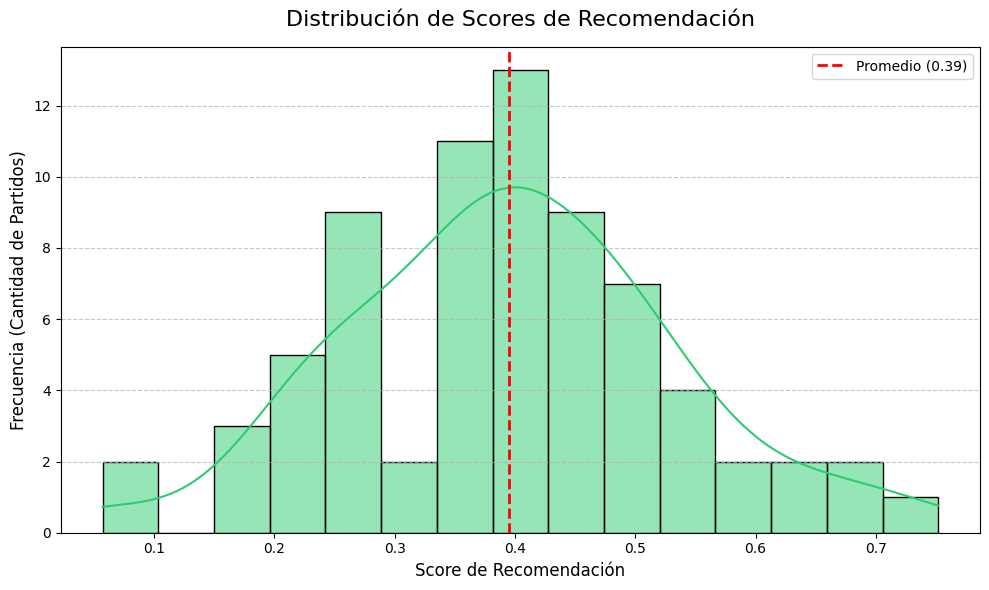

In [ ]:
# =====================================================================
# 3. MOSTRAR RESULTADOS Y GRÁFICO
# =====================================================================

# Seleccionamos las columnas más importantes para ver el Top 10
columnas_vista = [
    'home_team', 'away_team', 'Score_Recomendacion', 
    'Categoria','match_hora_utc', 'day_of_week_num'
]

print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(f"Pesos: {usuario_ejemplo["pesos"]}\n")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

# --- Generar el gráfico de distribución ---
plt.figure(figsize=(10, 6))
sns.histplot(
    df_recomendaciones['Score_Recomendacion'], 
    bins=15, 
    kde=True, 
    color='#2ecc71', 
    edgecolor='black'
)

plt.title('Distribución de Scores de Recomendación', fontsize=16, pad=15)
plt.xlabel('Score de Recomendación', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Partidos)', fontsize=12)

# Línea marcando el promedio
promedio = df_recomendaciones['Score_Recomendacion'].mean()
plt.axvline(promedio, color='red', linestyle='dashed', linewidth=2, label=f'Promedio ({promedio:.2f})')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
usuario_fanatico = {
    "nacionalidad": "Mexico",
    "pesos": {
        "w_nacionalidad": 100,  # Importancia absoluta
        "w_calidad_elo": 0,
        "w_paridad_elo": 0,
        "w_calidad_fifa": 0,    # Pesa 15% la calidad del futbol que quiere ver
        "w_paridad_fifa": 0,    # Pesa 10% que los partidos sean parejos
        "w_fin_de_semana": 0,
        "w_horario_libre": 0,
        "w_decisivo": 0
    },
    "horario_libre": {
        # Libre las 24hs del día (simulamos que no le importa el horario)
        0: list(range(0, 24)), 1: list(range(0, 24)), 2: list(range(0, 24)),
        3: list(range(0, 24)), 4: list(range(0, 24)), 5: list(range(0, 24)), 
        6: list(range(0, 24))
    }
}

df_recomendaciones = recomendar_partidos(matriz_partidos, usuario_fanatico)
print("🏆 TOP 10 PARTIDOS RECOMENDADOS:")
print(df_recomendaciones[columnas_vista].head(10).to_string(index=False))

🏆 TOP 10 PARTIDOS RECOMENDADOS:
     home_team          away_team  Score_Recomendacion             Categoria  match_hora_utc  day_of_week_num
        Mexico       South Africa                  1.0          Imperdible 🌟              19                3
        Mexico     Korea Republic                  1.0          Imperdible 🌟               1                4
       Czechia             Mexico                  1.0          Imperdible 🌟               1                3
Korea Republic            Czechia                  0.0 Para ver el resumen 📱               2                4
       Czechia       South Africa                  0.0 Para ver el resumen 📱              16                3
  South Africa     Korea Republic                  0.0 Para ver el resumen 📱               1                3
        Canada Bosnia-Herzegovina                  0.0 Para ver el resumen 📱              19                4
   Switzerland Bosnia-Herzegovina                  0.0 Para ver el resumen 📱            